In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')   # run this if you haven't already


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
DATASET_FOLDER = "D:/Brain Tumor/tumor_dataset/DATASET/Segmentation"

In [ ]:
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [3]:
os.listdir(DATASET_FOLDER)

['Glioma', 'Meningioma', 'Pituitary tumor']

In [4]:
# os.listdir(DATASET_FOLDER+"/Segmentation")

In [5]:
# sorted(os.listdir(DATASET_FOLDER+"/Glioma"))

In [6]:
import re

data = []
mask = []

In [7]:
for f in sorted(os.listdir(DATASET_FOLDER+"/Glioma")):
  if re.search(r'_mask.png', f):
    mask.append(f)
  else:
    data.append(f)

In [8]:
for f in sorted(os.listdir(DATASET_FOLDER+"/Meningioma")):
  if re.search(r'_mask.png', f):
    mask.append(f)
  else:
    data.append(f)

In [9]:
for f in sorted(os.listdir(DATASET_FOLDER+"/Pituitary tumor")):
  if re.search(r'_mask.png', f):
    mask.append(f)
  else:
    data.append(f)

In [10]:
data[10]

'enh_1851.png'

In [11]:
mask[10]

'enh_1851_mask.png'

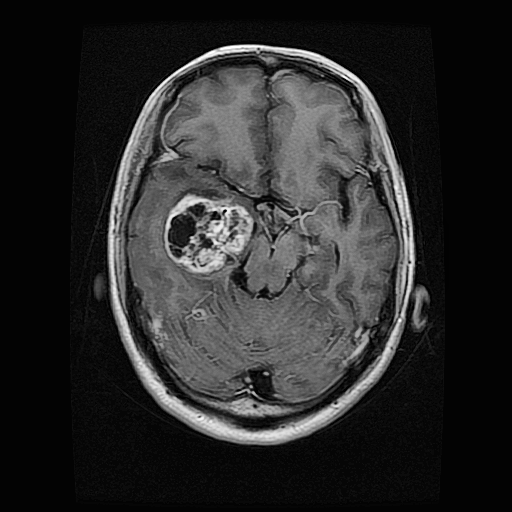

In [12]:
from PIL import Image

Image.open(DATASET_FOLDER+"/Glioma/"+data[0])

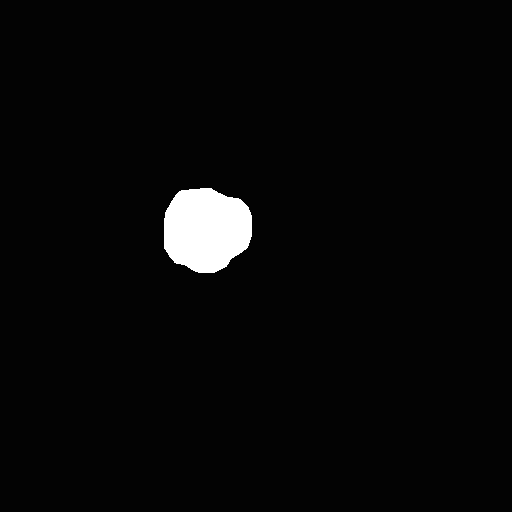

In [13]:
Image.open(DATASET_FOLDER+"/Glioma/"+mask[0])

In [17]:
import cv2

# data_path =  DATASET_FOLDER + "/Glioma/" + data[1]


# cv2.imshow("Glioma",cv2.imread(data_path))
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [16]:

# cv2.imshow("Glioma_1",(cv2.resize(cv2.imread(data_path), (256, 256))[15:230, 40:220]))
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [18]:
# img = cv2.resize(cv2.imread(data_path), (256, 256), cv2.IMREAD_GRAYSCALE)
# img = img.astype('float32')
# img = (img - img.mean()) / (img.std() + 1e-8)
# cv2.imshow("random", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# **Testing out Applying the Mask (what we should be looking at after everything is done)**

In [19]:
image = cv2.imread(DATASET_FOLDER+"/Glioma/"+data[0])
mask_ = cv2.imread(DATASET_FOLDER+"/Glioma/"+mask[0])

In [20]:
cv2.imshow("Tumor", image)

In [21]:
print(image.shape)
print(mask_.shape)

(512, 512, 3)
(512, 512, 3)


In [22]:
def apply_mask(image, mask_, alpha=0.6):
  img = image.astype('float32')
  mask = mask_.astype('float32')

  beta = 1- alpha
  gamma = 0
  overlay = cv2.addWeighted(img, alpha, mask, beta, gamma)

  return overlay.astype('uint8')


Text(0.5, 1.0, 'Glioma')

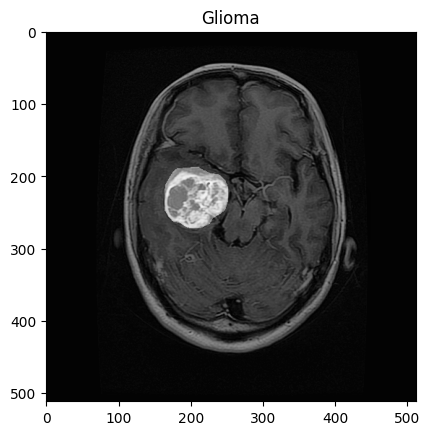

In [23]:
import matplotlib.pyplot as plt

img = apply_mask(image, mask_)
# cv2_imshow("Glioma",img)
# print("                              Glioma")
plt.imshow(img)
plt.title("Glioma")

# **Preprocessing for Segmentation**



In [24]:
## Note run only at the beginning of preprocessing else chud gaye

import shutil

if os.path.exists("preprocessed_data"):
  shutil.rmtree("preprocessed_data")
  os.mkdir("preprocessed_data")
  # os.mkdir("preprocessed_data/Glioma")
  # os.mkdir("preprocessed_data/Glioma/images")
  # os.mkdir("preprocessed_data/Glioma/masks")
  # os.mkdir("preprocessed_data/Meningioma")
  # os.mkdir("preprocessed_data/Meningioma/images")
  # os.mkdir("preprocessed_data/Meningioma/masks")
  # os.mkdir("preprocessed_data/Pituitary tumor")
  # os.mkdir("preprocessed_data/Pituitary tumor/images")
  # os.mkdir("preprocessed_data/Pituitary tumor/masks")
  os.mkdir("preprocessed_data/images")
  os.mkdir("preprocessed_data/masks")
else:
  os.mkdir("preprocessed_data")
  # os.mkdir("preprocessed_data/Glioma")
  # os.mkdir("preprocessed_data/Glioma/images")
  # os.mkdir("preprocessed_data/Glioma/masks")
  # os.mkdir("preprocessed_data/Meningioma")
  # os.mkdir("preprocessed_data/Meningioma/images")
  # os.mkdir("preprocessed_data/Meningioma/masks")
  # os.mkdir("preprocessed_data/Pituitary tumor")
  # os.mkdir("preprocessed_data/Pituitary tumor/images")
  # os.mkdir("preprocessed_data/Pituitary tumor/masks")
  os.mkdir("preprocessed_data/images")
  os.mkdir("preprocessed_data/masks")

In [25]:
# os.mkdir("preprocessed_data")
# os.mkdir("preprocessed_data/Glioma")
# os.mkdir("preprocessed_data/Meningioma")
# os.mkdir("preprocessed_data/Pituitary tumor")

In [26]:
import cv2

In [27]:
for f in os.listdir(DATASET_FOLDER):
  # j=0
  for i in sorted(os.listdir(DATASET_FOLDER+"/"+f)):
    # cv2.resize(cv2.imread(data_path), (256, 256), interpolation=cv2.INTER_LINEAR)
    if re.search(r'_mask.png', i):
      img = cv2.imread(DATASET_FOLDER+"/"+f+"/"+i, cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
      # img = (img > 127).astype('uint8')
      # cv2.imwrite("preprocessed_data/"+f+"/"+f+f"_{j}_mask.png", img)
      # cv2.imwrite("preprocessed_data/"+f+"/"+"masks/"+i, img)
      cv2.imwrite("preprocessed_data/masks/"+re.sub("_mask",'',i),img)

    else:
      img = cv2.imread(DATASET_FOLDER+"/"+f+"/"+i, cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
      # img = img.astype('float32')
      # img = (img - img.mean()) / (img.std() + 1e-8)
      # cv2.imwrite("preprocessed_data/"+f+"/"+f+f"_{j}.png", img)
      # cv2.imwrite("preprocessed_data/"+f+"/"+"images/"+i, img)
      cv2.imwrite("preprocessed_data/images/"+i,img)

    # cv2.imwrite("preprocessed_data/"+f+"/"+i, img)

    # j+=1


In [28]:
import os
import re

img_dir = "preprocessed_data/images/"
mask_dir = "preprocessed_data/masks/"

img_files = set(os.listdir(img_dir))
mask_files = set(os.listdir(mask_dir))


base_imgs = {os.path.splitext(f)[0] for f in img_files}
base_masks = {re.sub(r'_mask','',os.path.splitext(f)[0]) for f in mask_files}

print("Total images:", len(base_imgs))
print("Total masks:", len(base_masks))


no_mask = base_imgs - base_masks
print("Images without mask:", len(no_mask))
print(list(no_mask)[:10])

no_img = base_masks - base_imgs
print("Masks without image:", len(no_img))
print(list(no_img)[:10])



Total images: 2192
Total masks: 2192
Images without mask: 0
[]
Masks without image: 0
[]


In [29]:
import shutil

out_img_dir = "preprocessed_data/images_filtered/"

if no_mask==[] or no_img==[]:

  os.makedirs(out_img_dir, exist_ok=True)

  for fname in os.listdir(img_dir):
      base = os.path.splitext(fname)[0]
      if base in base_masks:  # only keep if mask exists
        shutil.copy(os.path.join(img_dir, fname),
                      os.path.join(out_img_dir, fname))

  print("Filtered images copied to", out_img_dir)

else:
  if os.path.exists(out_img_dir):
    shutil.rmtree(out_img_dir)




In [30]:
import tensorflow as tf

def load_and_preprocess_image_mask(image_path, mask_path, target_size=(256, 256)):
    
    
    
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_size, method='bilinear')

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    # mask = tf.image.convert_image_dtype(mask, tf.float32)
    # mask = tf.image.resize(mask, target_size, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR) # Use nearest neighbor for masks
    # mask = tf.cast(mask > 127, tf.uint8)                             # {0,1}
    mask = tf.image.resize(mask, target_size, method='nearest')      # preserve ids
    mask = tf.cast(mask > 128, tf.float32)                                  # int labels

    # Normalize image to [0, 1]
    # image = image / 255.0
    # mask = mask/255.0

    return image, mask

In [31]:
import os

image_dir = 'preprocessed_data/images'
mask_dir = 'preprocessed_data/masks'

image_filenames = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.png')])
mask_filenames = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.png')])

assert len(image_filenames) == len(mask_filenames), "Number of images and masks must match."

In [32]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(
    image_filenames, mask_filenames, test_size=0.2, random_state=42)

In [33]:
val_images[1]

'preprocessed_data/images\\enh_1475.png'

In [34]:
val_masks[1]

'preprocessed_data/masks\\enh_1475.png'

In [35]:
cv2.imshow("image", cv2.imread(val_images[1]))

In [36]:
# mask_filenames[:10]

In [37]:
# mask_filenames.count('preprocessed_data/masks/enh_1_mask.png')

In [38]:
# cv2.imread("/content/preprocessed_data/images/enh_1.png")

In [39]:
# dataset = tf.data.Dataset.from_tensor_slices((image_filenames, mask_filenames))
# dataset = dataset.map(load_and_preprocess_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_dataset = train_dataset.map(load_and_preprocess_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_dataset = val_dataset.map(load_and_preprocess_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

In [40]:
BUFFER_SIZE = 1000 # For shuffling
BATCH_SIZE = 32

# dataset = dataset.shuffle(BUFFER_SIZE)
# dataset = dataset.batch(BATCH_SIZE)
# dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)


In [41]:
# normalization_layer = tf.keras.layers.Rescaling(1./255)
# testing = dataset.map(lambda x, y: (normalization_layer(x), y))

In [42]:
image_filenames = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.png')])
mask_filenames = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.png')])

In [43]:
import numpy as np

for x,y in train_dataset.take(1):
  print(x.shape)
  print(y.shape)
  print(np.min(x))
  print(np.max(x))
  print(np.min(y))
  print(np.max(y))

(32, 256, 256, 3)
(32, 256, 256, 1)
0.003921569
1.0
0.0
1.0


In [44]:
# for x,y in dataset.take(1):
#   plt.imshow(x[0])
#   plt.imshow(y[0])

# **Preprocessing for Classification**

In [45]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds

In [46]:
CLASSIFICATION_FOLDER = "D:\Brain Tumor/tumor_dataset/DATASET/classification/Testing"

In [47]:
# # data = tf.keras.utils.get_file(DATASET_FOLDER)
# data = tf.keras.utils.image_dataset_from_directory(CLASSIFICATION_FOLDER)

In [48]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_FOLDER,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256, 256),
    batch_size=32
  )

Found 1311 files belonging to 4 classes.
Using 1049 files for training.


In [49]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_FOLDER,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256, 256),
    batch_size=32
)

Found 1311 files belonging to 4 classes.
Using 262 files for validation.


In [50]:
class_names = train_ds.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

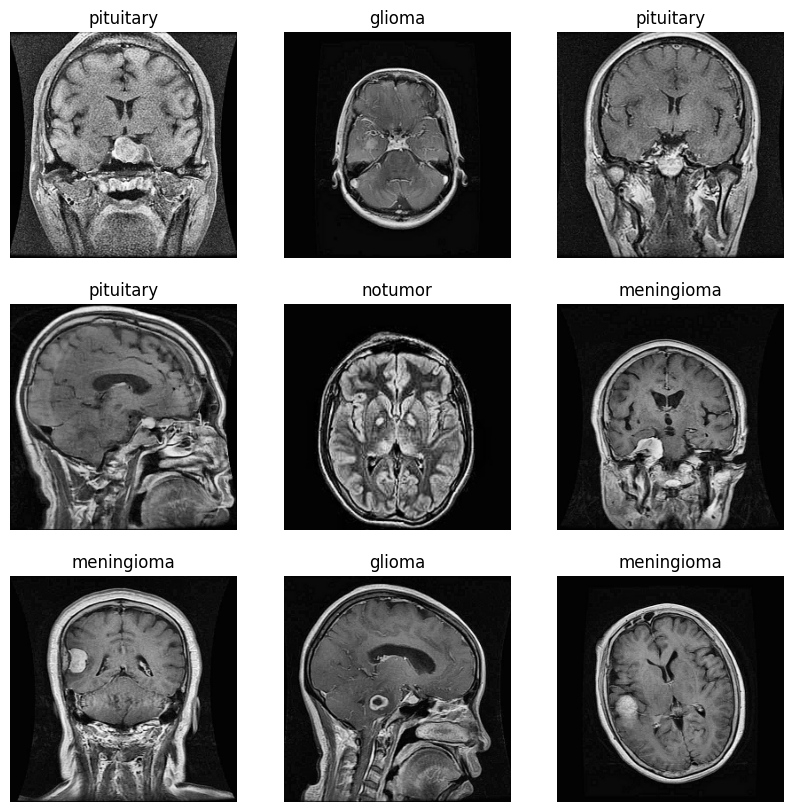

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [52]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [53]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 0.99705887


In [54]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# **Building the Model**

In [55]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Conv2DTranspose, concatenate, Input

In [56]:
from tensorflow.keras import Sequential

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

In [ ]:
def EncoderMiniBlock(inputs, n_filters=32, dropout_prob=0.3, max_pooling=True):
    conv = Conv2D(n_filters,
                  3,  # filter size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(inputs)
    conv = Conv2D(n_filters,
                  3,  # filter size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(conv)

    conv = BatchNormalization()(conv, training=False)
    if dropout_prob > 0:
        conv = tf.keras.layers.Dropout(dropout_prob)(conv)
    if max_pooling:
        next_layer = tf.keras.layers.MaxPooling2D(pool_size = (2,2))(conv)
    else:
        next_layer = conv
    skip_connection = conv
    return next_layer, skip_connection

In [58]:
def DecoderMiniBlock(prev_layer_input, skip_layer_input, n_filters=32):
    up = Conv2DTranspose(
                 n_filters,
                 (3,3),
                 strides=(2,2),
                 padding='same')(prev_layer_input)
    merge = concatenate([up, skip_layer_input], axis=3)
    conv = Conv2D(n_filters,
                 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(merge)
    conv = Conv2D(n_filters,
                 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(conv)
    return conv

In [59]:
def UNetCompiled(input_size=(128, 128, 3), n_filters=32, n_classes=3):
  """
  Combine both encoder and decoder blocks according to the U-Net research paper
  Return the model as output
  """
  # Input size represent the size of 1 image (the size used for pre-processing)
  inputs = Input(input_size)

  # Encoder includes multiple convolutional mini blocks with different maxpooling, dropout and filter parameters
  # Observe that the filters are increasing as we go deeper into the network which will increasse the # channels of the image
  cblock1 = EncoderMiniBlock(inputs, n_filters,dropout_prob=0, max_pooling=True)
  cblock2 = EncoderMiniBlock(cblock1[0],n_filters*2,dropout_prob=0, max_pooling=True)
  cblock3 = EncoderMiniBlock(cblock2[0], n_filters*4,dropout_prob=0, max_pooling=True)
  cblock4 = EncoderMiniBlock(cblock3[0], n_filters*8,dropout_prob=0.3, max_pooling=True)
  cblock5 = EncoderMiniBlock(cblock4[0], n_filters*16, dropout_prob=0.3, max_pooling=False)

  # Decoder includes multiple mini blocks with decreasing number of filters
  # Observe the skip connections from the encoder are given as input to the decoder
  # Recall the 2nd output of encoder block was skip connection, hence cblockn[1] is used
  ublock6 = DecoderMiniBlock(cblock5[0], cblock4[1],  n_filters * 8)
  ublock7 = DecoderMiniBlock(ublock6, cblock3[1],  n_filters * 4)
  ublock8 = DecoderMiniBlock(ublock7, cblock2[1],  n_filters * 2)
  ublock9 = DecoderMiniBlock(ublock8, cblock1[1],  n_filters)

  # Complete the model with 1 3x3 convolution layer (Same as the prev Conv Layers)
  # Followed by a 1x1 Conv layer to get the image to the desired size.
  # Observe the number of channels will be equal to number of output classes
  conv9 = Conv2D(n_filters,
                3,
                activation='relu',
                padding='same',
                kernel_initializer='he_normal')(ublock9)

  conv10 = Conv2D(1, 1, activation='sigmoid', padding='same')(conv9)

  # Define the model
  model = tf.keras.Model(inputs=inputs, outputs=conv10)

  return model

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(image_filenames, mask_filenames, test_size=0.2, random_state=36)

In [61]:
X_train

['preprocessed_data/images\\enh_1977.png',
 'preprocessed_data/images\\enh_249.png',
 'preprocessed_data/images\\enh_51.png',
 'preprocessed_data/images\\enh_364.png',
 'preprocessed_data/images\\enh_1438.png',
 'preprocessed_data/images\\enh_328.png',
 'preprocessed_data/images\\enh_2216.png',
 'preprocessed_data/images\\enh_1005.png',
 'preprocessed_data/images\\enh_1536.png',
 'preprocessed_data/images\\enh_621.png',
 'preprocessed_data/images\\enh_1150.png',
 'preprocessed_data/images\\enh_80.png',
 'preprocessed_data/images\\enh_337.png',
 'preprocessed_data/images\\enh_2293.png',
 'preprocessed_data/images\\enh_2179.png',
 'preprocessed_data/images\\enh_2110.png',
 'preprocessed_data/images\\enh_1212.png',
 'preprocessed_data/images\\enh_450.png',
 'preprocessed_data/images\\enh_2091.png',
 'preprocessed_data/images\\enh_2305.png',
 'preprocessed_data/images\\enh_513.png',
 'preprocessed_data/images\\enh_215.png',
 'preprocessed_data/images\\enh_1544.png',
 'preprocessed_data/ima

In [62]:
Y_train

['preprocessed_data/masks\\enh_1977.png',
 'preprocessed_data/masks\\enh_249.png',
 'preprocessed_data/masks\\enh_51.png',
 'preprocessed_data/masks\\enh_364.png',
 'preprocessed_data/masks\\enh_1438.png',
 'preprocessed_data/masks\\enh_328.png',
 'preprocessed_data/masks\\enh_2216.png',
 'preprocessed_data/masks\\enh_1005.png',
 'preprocessed_data/masks\\enh_1536.png',
 'preprocessed_data/masks\\enh_621.png',
 'preprocessed_data/masks\\enh_1150.png',
 'preprocessed_data/masks\\enh_80.png',
 'preprocessed_data/masks\\enh_337.png',
 'preprocessed_data/masks\\enh_2293.png',
 'preprocessed_data/masks\\enh_2179.png',
 'preprocessed_data/masks\\enh_2110.png',
 'preprocessed_data/masks\\enh_1212.png',
 'preprocessed_data/masks\\enh_450.png',
 'preprocessed_data/masks\\enh_2091.png',
 'preprocessed_data/masks\\enh_2305.png',
 'preprocessed_data/masks\\enh_513.png',
 'preprocessed_data/masks\\enh_215.png',
 'preprocessed_data/masks\\enh_1544.png',
 'preprocessed_data/masks\\enh_1531.png',
 'pr

In [67]:
# Call the helper function for defining the layers for the model, given the input image size
unet = UNetCompiled(input_size=(256,256,3), n_filters=32, n_classes=1)

In [68]:
unet.summary()

Model: "functional"

﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ Layer (type)        ﷿﷿﷿ Output Shape      ﷿﷿﷿    Param # ﷿﷿﷿ Connected to      ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ input_layer         ﷿﷿﷿ (None, 256, 256,  ﷿﷿﷿          0 ﷿﷿﷿ -                 ﷿﷿﷿
﷿﷿﷿ (InputLayer)        ﷿﷿﷿ 3)                ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ conv2d (Conv2D)     ﷿﷿﷿ (None, 256, 256,  ﷿﷿﷿        896 ﷿﷿﷿ input_layer[0][0] ﷿﷿﷿
﷿﷿﷿                     ﷿﷿﷿ 32)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ conv2d_1 (Conv2D)   ﷿﷿﷿ (None, 256, 256,  ﷿﷿﷿      9,248 ﷿﷿﷿ conv2d[0][0]      ﷿﷿﷿
﷿﷿﷿                     ﷿﷿﷿ 32)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ batch_normalization ﷿﷿﷿ (None, 256, 256,  ﷿﷿﷿        128 ﷿﷿﷿ conv2d_1[0][0]    ﷿﷿﷿
﷿﷿﷿ (BatchNormalizatio﷿﷿﷿ ﷿﷿﷿ 32)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ max_pooling2d       ﷿﷿﷿ (None, 128, 128,  ﷿﷿﷿          0 ﷿﷿﷿ batch_normalizat﷿﷿﷿ ﷿﷿﷿
﷿﷿﷿ (MaxPooling2D)      ﷿﷿﷿ 32)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ conv2d_2 (Conv2D)   ﷿﷿﷿ (None, 128, 128,  ﷿﷿﷿     18,496 ﷿﷿﷿ max_pooling2d[0]﷿﷿﷿ ﷿﷿﷿
﷿﷿﷿                     ﷿﷿﷿ 64)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ conv2d_3 (Conv2D)   ﷿﷿﷿ (None, 128, 128,  ﷿﷿﷿     36,928 ﷿﷿﷿ conv2d_2[0][0]    ﷿﷿﷿
﷿﷿﷿                     ﷿﷿﷿ 64)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ batch_normalizatio﷿﷿﷿ ﷿﷿﷿ (None, 128, 128,  ﷿﷿﷿        256 ﷿﷿﷿ conv2d_3[0][0]    ﷿﷿﷿
﷿﷿﷿ (BatchNormalizatio﷿﷿﷿ ﷿﷿﷿ 64)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
﷿﷿﷿ max_pooling2d_1     ﷿﷿﷿ (None, 64, 64,    ﷿﷿﷿          0 ﷿﷿﷿ batch_normalizat﷿﷿﷿ ﷿﷿﷿
﷿﷿﷿ (MaxPooling2D)      ﷿﷿﷿ 64)               ﷿﷿﷿            ﷿﷿﷿                   ﷿﷿﷿
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

 Total params: 8,643,713 (32.97 MB)

 Trainable params: 8,641,729 (32.97 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [69]:
# STEPS_PER_EPOCH = train_dataset // BATCH_SIZE

In [70]:
for images, masks in train_dataset.take(2):
  sample_image, sample_mask = images[0], masks[0]
  display([sample_image, sample_mask])

[<tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
 array([[[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        ...,
 
        [[0.01176471, 0.01176471

[<tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
 array([[[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        ...,
 
        [[0.01176471, 0.01176471

In [71]:
from IPython.display import clear_output

In [72]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [73]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in train_dataset.take(num):
      pred_mask = unet.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(unet.predict(sample_image[tf.newaxis, ...]))])

In [74]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

In [75]:
len(train_dataset)

55

In [76]:
len(val_dataset)

14

In [77]:
train_dataset_steps = len(train_dataset)// BATCH_SIZE
val_dataset_steps = len(val_dataset)// BATCH_SIZE

In [78]:
# unet.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

unet.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

results = unet.fit(train_dataset, epochs=20, verbose=1, validation_data=val_dataset, callbacks=[DisplayCallback()])

1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 237ms/step


[<tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
 array([[[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        [[0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         ...,
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471],
         [0.01176471, 0.01176471, 0.01176471]],
 
        ...,
 
        [[0.01176471, 0.01176471


Sample Prediction after epoch 20

55/55 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 633s 12s/step - accuracy: 0.9960 - loss: 0.0101 - val_accuracy: 0.9925 - val_loss: 0.0308


1/1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0s 287ms/step


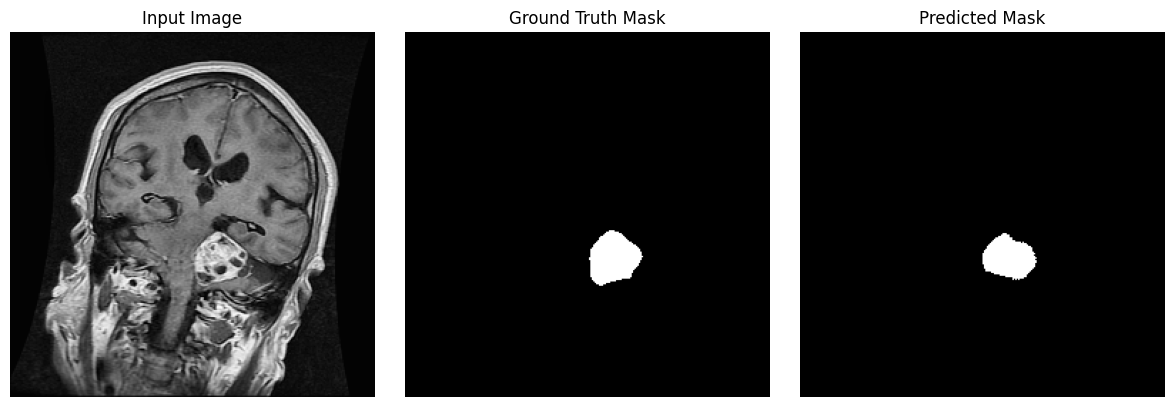

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Pick a random example from your test set
for image, mask in val_dataset.take(1):   # <-- change to val_dataset if test_dataset not defined
    sample_image = image[4]     # first image in batch
    sample_mask = mask[4]       # its corresponding true mask
    break

# Predict mask for the image
pred_mask = unet.predict(tf.expand_dims(sample_image, axis=0))[0]  # shape: (H, W, 1)

# Convert prediction probabilities [0,1] -> binary mask
pred_mask_bin = (pred_mask > 0.5).astype(np.float32)

# Plot everything
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Input Image')
plt.imshow(sample_image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Ground Truth Mask')
plt.imshow(sample_mask[..., 0], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Predicted Mask')
plt.imshow(pred_mask_bin[..., 0], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


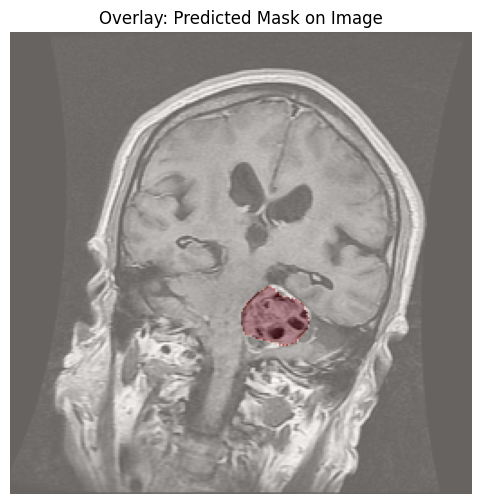

In [89]:
plt.figure(figsize=(6,6))
plt.title('Overlay: Predicted Mask on Image')
plt.imshow(sample_image)
plt.imshow(pred_mask_bin[..., 0], cmap='Reds', alpha=0.4)  # overlay in red
plt.axis('off')
plt.show()


In [70]:
def LoadData (path1, path2):
    """
    Looks for relevant filenames in the shared path
    Returns 2 lists for original and masked files respectively
    
    """
    # Read the images folder like a list
    image_dataset = os.listdir(path1)
    mask_dataset = os.listdir(path2)

    # Make a list for images and masks filenames
    orig_img = []
    mask_img = []
    for file in image_dataset:
        orig_img.append(file)
    for file in mask_dataset:
        mask_img.append(file)

    # Sort the lists to get both of them in same order (the dataset has exactly the same name for images and corresponding masks)
    orig_img.sort()
    mask_img.sort()
    
    return orig_img, mask_img

In [90]:
unet.save("unet_brain_tumor_segmentation_model.h5")

In [71]:
def PreprocessData(img, mask, target_shape_img, target_shape_mask, path1, path2):
    """
    Processes the images and mask present in the shared list and path
    Returns a NumPy dataset with images as 3-D arrays of desired size
    Please note the masks in this dataset have only one channel
    """
    # Pull the relevant dimensions for image and mask
    m = len(img)                     # number of images
    i_h,i_w,i_c = target_shape_img   # pull height, width, and channels of image
    m_h,m_w,m_c = target_shape_mask  # pull height, width, and channels of mask
    
    # Define X and Y as number of images along with shape of one image
    X = np.zeros((m,i_h,i_w,i_c), dtype=np.float32)
    y = np.zeros((m,m_h,m_w,m_c), dtype=np.int32)
    
    # Resize images and masks
    for file in img:
        # convert image into an array of desired shape (3 channels)
        index = img.index(file)
        path = os.path.join(path1, file)
        single_img = Image.open(path).convert('RGB')
        single_img = single_img.resize((i_h,i_w))
        single_img = np.reshape(single_img,(i_h,i_w,i_c)) 
        single_img = single_img/256.
        X[index] = single_img
        
        # convert mask into an array of desired shape (1 channel)
        single_mask_ind = mask[index]
        path = os.path.join(path2, single_mask_ind)
        single_mask = Image.open(path)
        single_mask = single_mask.resize((m_h, m_w))
        single_mask = np.reshape(single_mask,(m_h,m_w,m_c)) 
        single_mask = single_mask - 1 # to ensure classes #s start from 0
        y[index] = single_mask
    return X, y

In [ ]:
""" Load Train Set and view some examples """
# Call the apt function
path1 = '/content/drive/My Drive/U-NET - Implementation/images/original/'
path2 = '/content/drive/My Drive/U-NET - Implementation/images/masks/'
img, mask = LoadData (path1, path2)

# View an example of image and corresponding mask 
show_images = 1
for i in range(show_images):
    img_view  = imageio.imread(path1 + img[i])
    mask_view = imageio.imread(path2 + mask[i])
    print(img_view.shape)
    print(mask_view.shape)
    fig, arr = plt.subplots(1, 2, figsize=(15, 15))
    arr[0].imshow(img_view)
    arr[0].set_title('Image '+ str(i))
    arr[1].imshow(mask_view)
    arr[1].set_title('Masked Image '+ str(i))